In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

Librerías cargadas ✅


In [3]:
df = pd.read_csv('../df_filtrado.csv.zip', compression='zip')
print(f"Datos cargados: {df.shape[0]:,} filas x {df.shape[1]} columnas ✅")
df.head()

Datos cargados: 470,818 filas x 20 columnas ✅


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_JORNADA,COLE_MCPIO_UBICACION,ESTU_FECHANACIMIENTO,ESTU_GENERO,ESTU_PAIS_RESIDE,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PUNT_GLOBAL,PUNT_MATEMATICAS
0,20224,URBANO,N,MIXTO,UNICA,GRANADA,03/09/2004,F,COLOMBIA,Dos,Ninguno,Ninguno,Estrato 1,5 a 6,No,No,No,No,196.0,26.0
1,20224,URBANO,N,MIXTO,SABATINA,CHOACHÍ,10/02/2005,M,COLOMBIA,Tres,Secundaria (Bachillerato) incompleta,Primaria completa,Estrato 1,3 a 4,No,Si,Si,Si,258.0,60.0
2,20224,URBANO,NaN,MIXTO,COMPLETA,SOACHA,27/12/2004,M,COLOMBIA,NaN,Técnica o tecnológica completa,Secundaria (Bachillerato) completa,Estrato 2,NaN,NaN,NaN,Si,NaN,285.0,61.0
3,20224,URBANO,N,MIXTO,COMPLETA,SOACHA,25/06/2006,F,COLOMBIA,Tres,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,No,Si,Si,Si,302.0,54.0
4,20224,RURAL,N,MIXTO,SABATINA,SASAIMA,18/05/2006,M,COLOMBIA,Dos,Técnica o tecnológica completa,No Aplica,Estrato 2,1 a 2,No,No,Si,Si,241.0,45.0


In [7]:
# Variables de la pregunta 2
columnas_p2 = [
    'PUNT_GLOBAL',
    'ESTU_GENERO',
    'COLE_AREA_UBICACION',
    'COLE_BILINGUE',
    'COLE_GENERO',
    'COLE_MCPIO_UBICACION',
    'FAMI_CUARTOSHOGAR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_PERSONASHOGAR',
    'FAMI_TIENEAUTOMOVIL',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENELAVADORA',
    'PERIODO'
]

df_p2 = df[columnas_p2].copy()
print(f"Shape: {df_p2.shape}")

# Nulos en cantidad y porcentaje
nulos = df_p2.isnull().sum()
porcentaje = (nulos / len(df_p2) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})
print(f"\nValores nulos:\n{resumen_nulos}")

Shape: (470818, 16)

Valores nulos:
                       Nulos  Porcentaje (%)
PUNT_GLOBAL           171841           36.50
ESTU_GENERO              265            0.06
COLE_AREA_UBICACION      198            0.04
COLE_BILINGUE          77355           16.43
COLE_GENERO                0            0.00
COLE_MCPIO_UBICACION       0            0.00
FAMI_CUARTOSHOGAR       6558            1.39
FAMI_EDUCACIONMADRE    10699            2.27
FAMI_EDUCACIONPADRE    10753            2.28
FAMI_ESTRATOVIVIENDA   11609            2.47
FAMI_PERSONASHOGAR      6620            1.41
FAMI_TIENEAUTOMOVIL     6736            1.43
FAMI_TIENECOMPUTADOR    7473            1.59
FAMI_TIENEINTERNET      9766            2.07
FAMI_TIENELAVADORA      6420            1.36
PERIODO                    0            0.00


In [17]:
a= df['FAMI_ESTRATOVIVIENDA'].value_counts()


In [8]:
# Eliminar filas con nulos
df_p2 = df_p2.dropna()
print(f"Filas después de limpiar nulos: {df_p2.shape[0]:,}")

# Codificar variables categóricas
le = LabelEncoder()
cols_categoricas = df_p2.select_dtypes(include=['object', 'category']).columns

for col in cols_categoricas:
    df_p2[col] = le.fit_transform(df_p2[col].astype(str))

print(f"\nVariables codificadas: {list(cols_categoricas)}")
df_p2.head()

Filas después de limpiar nulos: 231,424

Variables codificadas: ['ESTU_GENERO', 'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO', 'COLE_MCPIO_UBICACION', 'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA']


,PUNT_GLOBAL,ESTU_GENERO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_MCPIO_UBICACION,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PERIODO
0,196.0,0,1,0,2,56,3,2,2,0,2,0,0,0,0,20224
1,258.0,1,1,0,2,25,9,9,6,0,1,0,1,1,1,20224
3,302.0,0,1,0,2,118,9,8,8,1,1,0,1,1,1,20224
4,241.0,1,0,0,2,111,3,10,3,1,0,0,0,1,1,20224
6,301.0,1,1,0,2,139,3,9,7,1,0,0,1,0,1,20224


In [ ]:
# K-medoids es lento con millones de filas
# Usamos una muestra representativa de 10,000 registros
df_muestra = df_p2.sample(n=10000, random_state=42)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_muestra)


Muestra lista: (10000, 16) ✅


k=2 ✅
k=3 ✅
k=4 ✅
k=5 ✅
k=6 ✅
k=7 ✅
k=8 ✅
k=9 ✅
k=10 ✅
k=11 ✅
k=12 ✅


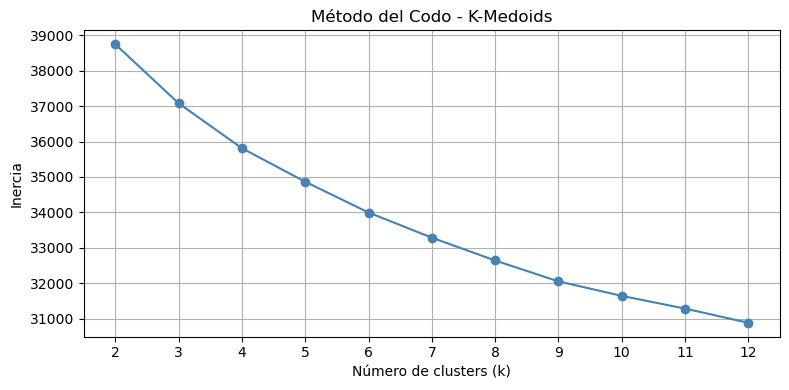

In [ ]:
# Probar con 2 a 8 clusters
inertias = []
k_valores = range(2, 9)

for k in k_valores:
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    kmedoids.fit(X_scaled)
    inertias.append(kmedoids.inertia_)
    print(f"k={k} ✅")

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(k_valores, inertias, marker='o', color='steelblue')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo - K-Medoids')
plt.xticks(k_valores)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Entrenar con k=4
kmedoids_final = KMedoids(n_clusters=4, random_state=42, method='pam')
kmedoids_final.fit(X_scaled)

# Agregar cluster al dataframe
df_muestra = df_muestra.copy()
df_muestra['cluster'] = kmedoids_final.labels_

print("Distribución de clusters:")
print(df_muestra['cluster'].value_counts().sort_index())

Distribución de clusters:
cluster
0    2607
1    1957
2    2386
3    3050
Name: count, dtype: int64


In [13]:
# Promedio de cada variable por cluster
perfil = df_muestra.groupby('cluster').mean().round(2)
print("Perfil promedio por cluster:")
perfil

Perfil promedio por cluster:


,PUNT_GLOBAL,ESTU_GENERO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_MCPIO_UBICACION,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PERIODO
cluster,,,,,,,,,,,,,,,,
0,263.51,0.97,0.85,0.00,2.00,96.70,5.63,7.69,7.47,1.16,3.02,0.22,0.75,0.77,0.91,20190.07
1,283.27,0.36,0.69,0.07,1.93,70.25,6.23,4.40,4.68,2.12,2.62,0.92,0.91,0.90,0.96,20192.23
2,240.93,0.38,0.80,0.00,2.00,81.86,4.78,7.06,6.64,0.67,6.43,0.07,0.17,0.07,0.29,20167.91
3,258.59,0.13,0.86,0.00,1.97,76.63,5.69,7.29,6.94,1.06,5.34,0.12,0.84,0.79,0.92,20175.38


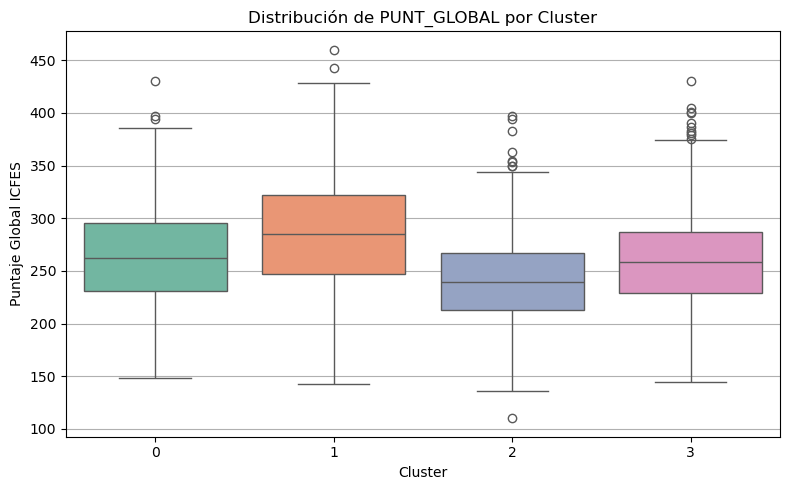

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_muestra, x='cluster', y='PUNT_GLOBAL', palette='Set2')
plt.title('Distribución de PUNT_GLOBAL por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Puntaje Global ICFES')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

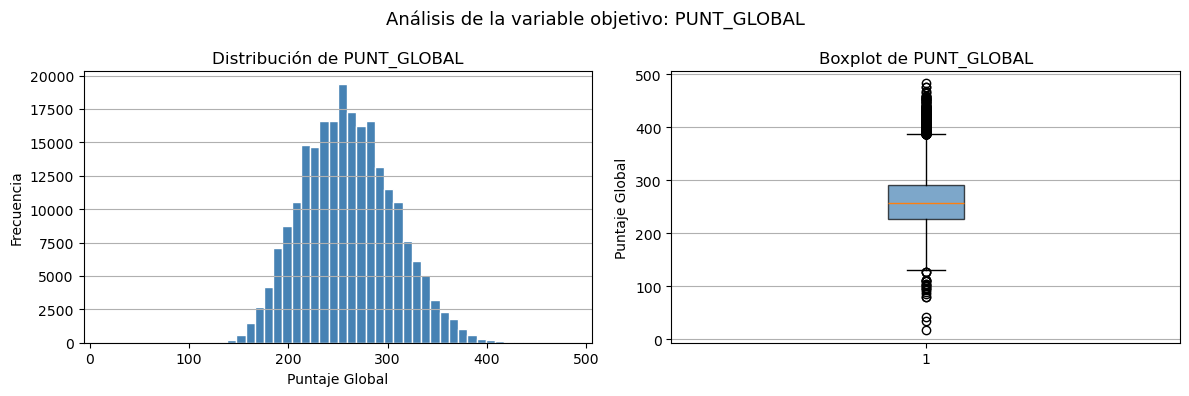

count    231424.00
mean        260.41
std          46.00
min          17.00
25%         227.00
50%         258.00
75%         291.00
max         483.00
Name: PUNT_GLOBAL, dtype: float64

Asimetría: 0.244


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df_p2['PUNT_GLOBAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de PUNT_GLOBAL')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, axis='y')

# Boxplot
axes[1].boxplot(df_p2['PUNT_GLOBAL'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de PUNT_GLOBAL')
axes[1].set_ylabel('Puntaje Global')
axes[1].grid(True, axis='y')

plt.suptitle('Análisis de la variable objetivo: PUNT_GLOBAL', fontsize=13)
plt.tight_layout()
plt.show()

# Estadísticas
print(df_p2['PUNT_GLOBAL'].describe().round(2))
print(f"\nAsimetría: {df_p2['PUNT_GLOBAL'].skew().round(3)}")

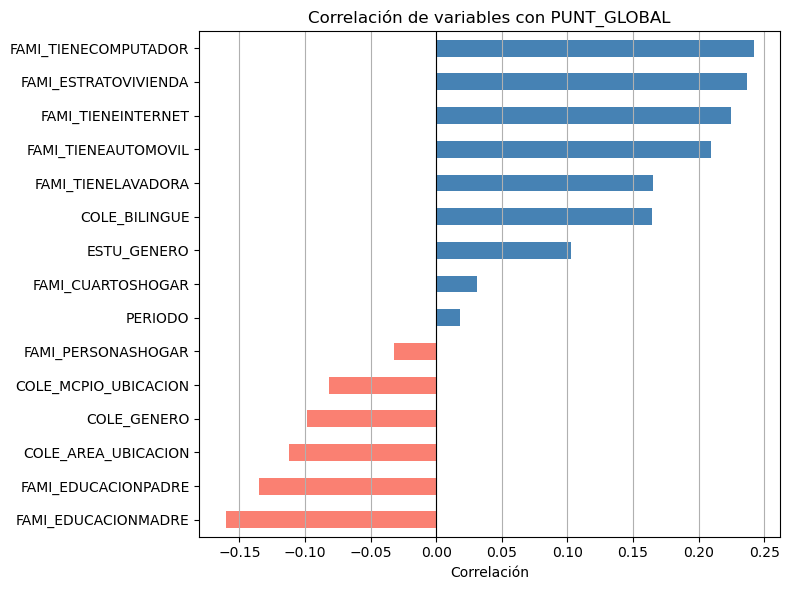


Top 5 variables más correlacionadas:
FAMI_TIENECOMPUTADOR    0.241889
FAMI_ESTRATOVIVIENDA    0.236783
FAMI_TIENEINTERNET      0.224838
FAMI_TIENEAUTOMOVIL     0.209353
FAMI_TIENELAVADORA      0.165446
Name: PUNT_GLOBAL, dtype: float64


In [30]:
# Correlación de todas las variables con PUNT_GLOBAL
correlaciones = df_p2.corr()['PUNT_GLOBAL'].drop('PUNT_GLOBAL').sort_values()

plt.figure(figsize=(8, 6))
correlaciones.plot(kind='barh', color=['salmon' if x < 0 else 'steelblue' for x in correlaciones])
plt.title('Correlación de variables con PUNT_GLOBAL')
plt.xlabel('Correlación')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 5 variables más correlacionadas:")
print(correlaciones.abs().sort_values(ascending=False).head(5))

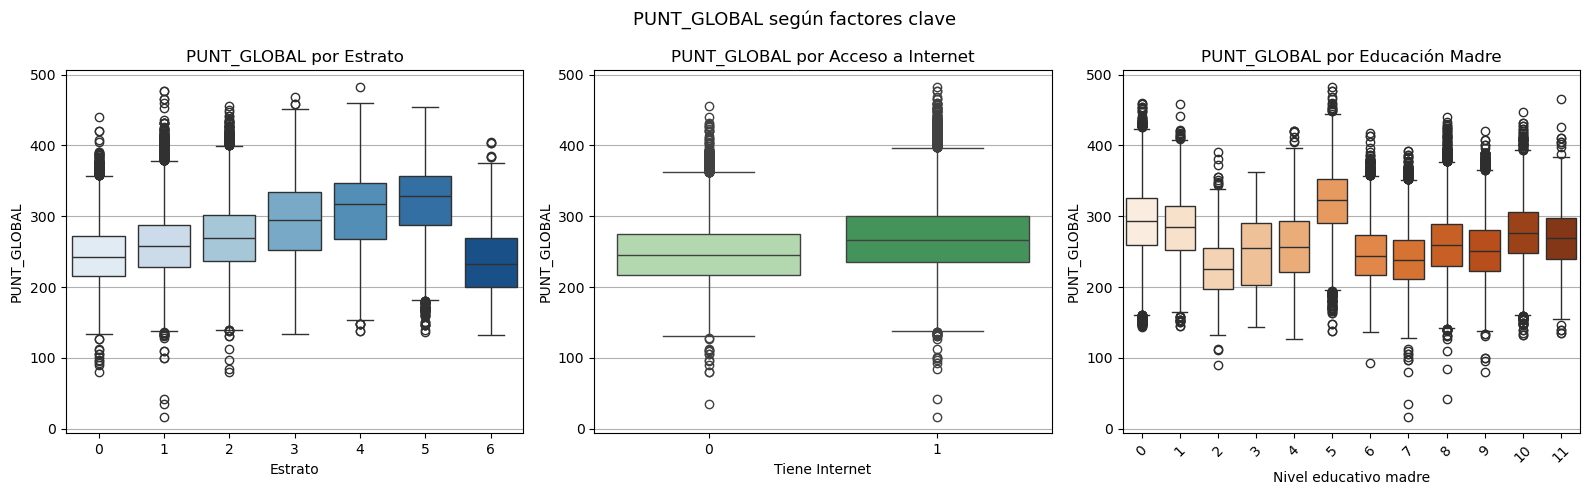

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Estrato
sns.boxplot(data=df_p2, x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', 
            palette='Blues', ax=axes[0])
axes[0].set_title('PUNT_GLOBAL por Estrato')
axes[0].set_xlabel('Estrato')
axes[0].grid(True, axis='y')

# Internet
sns.boxplot(data=df_p2, x='FAMI_TIENEINTERNET', y='PUNT_GLOBAL',
            palette='Greens', ax=axes[1])
axes[1].set_title('PUNT_GLOBAL por Acceso a Internet')
axes[1].set_xlabel('Tiene Internet')
axes[1].grid(True, axis='y')

# Educación madre
sns.boxplot(data=df_p2, x='FAMI_EDUCACIONMADRE', y='PUNT_GLOBAL',
            palette='Oranges', ax=axes[2])
axes[2].set_title('PUNT_GLOBAL por Educación Madre')
axes[2].set_xlabel('Nivel educativo madre')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, axis='y')

plt.suptitle('PUNT_GLOBAL según factores clave', fontsize=13)
plt.tight_layout()
plt.show()